# 実験結果の可視化

`outputs/` ディレクトリ内に保存された実験結果（`log.json`）を再帰的に走査し，同一条件（実験・手法・
ハイパーパラメータ）における全Seedの結果から平均と標準偏差を計算してプロットする．

比較対象とする実験・手法・ハイパーパラメータは，「可視化する条件の指定」のセルの変数で指定する．
生成したグラフは `outputs/{experiment}/` 以下に保存する．

`OUTPUTS_ROOT` を `outputs_old` に変更すると，`.orders/order_020.md` 以前の事前実験
（`programs_old/`）の結果も同じ手順で可視化できる．

In [1]:
import json
import os
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np

# 日本語ラベルを正しく描画するため，IPAexゴシックフォントが存在すれば明示的に登録する
_JP_FONT_PATH = "/usr/share/fonts/opentype/ipaexfont-gothic/ipaexg.ttf"
if os.path.exists(_JP_FONT_PATH):
    fm.fontManager.addfont(_JP_FONT_PATH)
    plt.rcParams["font.family"] = fm.FontProperties(fname=_JP_FONT_PATH).get_name()
plt.rcParams["axes.unicode_minus"] = False

# 可視化対象の出力ディレクトリ．事前実験を見る場合は "outputs_old" に変更する．
OUTPUTS_ROOT = Path("outputs")

## 結果の読み込み

`outputs/{experiment}/{method}/{hyperparams}/{seed}/log.json` を再帰的に走査し，
`(experiment, method, hyperparams)` ごとに全Seedのログと設定を集約する．

In [2]:
def load_all_results(outputs_root: Path) -> dict:
    """
    概要: `outputs/` 以下の全 `log.json` を再帰的に読み込み，(experiment, method, hyperparams)
        をキーとして，Seedごとのログのリストにまとめる．
    引数: outputs_root (Path)．走査対象のルートディレクトリ．
    戻り値: results (dict)．
        key: (experiment, method, hyperparams) のタプル（いずれも str）．
        value: {"seed_logs": [dict, ...], "configs": [dict, ...], "seeds": [int, ...]}
    """
    results = {}
    for log_path in sorted(outputs_root.glob("*/*/*/*/log.json")):
        seed_dir = log_path.parent
        hp_dir = seed_dir.parent
        method_dir = hp_dir.parent
        experiment_dir = method_dir.parent

        key = (experiment_dir.name, method_dir.name, hp_dir.name)
        with open(log_path) as f:
            log = json.load(f)

        config_path = seed_dir / "config.json"
        config = {}
        if config_path.exists():
            with open(config_path) as f:
                config = json.load(f)

        entry = results.setdefault(key, {"seed_logs": [], "configs": [], "seeds": []})
        entry["seed_logs"].append(log)
        entry["configs"].append(config)
        entry["seeds"].append(seed_dir.name)
    return results


all_results = load_all_results(OUTPUTS_ROOT)
for (experiment, method, hyperparams), entry in all_results.items():
    print(f"{experiment} / {method} / {hyperparams}: {len(entry['seed_logs'])} seeds")

ex000_a9a_least_squares / ASAI_SVRG / eta1.545485e-01_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / ASAI_SVRG / eta2.318228e-02_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / ASAI_SVRG / eta7.910960e-07_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / NFG_SVRG / eta1.545485e-01_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / NFG_SVRG / eta2.318228e-02_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / NFG_SVRG / eta7.910960e-07_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / SGD / eta1.545485e-01_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / SGD / eta2.318228e-02_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / SGD / eta7.910960e-07_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / SVRG / eta1.545485e-01_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / SVRG / eta2.318228e-02_K29304_epochs100: 5 seeds
ex000_a9a_least_squares / SVRG / eta7.910960e-07_K29304_epochs100: 5 seeds
ex001_mushroom_logistic / ASAI_SVRG / eta1.049767e-02_lambda9.155984e-01_K73

## 平均・標準偏差の計算

同一条件の全Seedのログについて，指定した横軸・縦軸それぞれの平均値と標準偏差を計算する．
横軸（`full_grad_computations`，`epoch`，`elapsed_time`）はSeedによって僅かに異なる場合がある
ため（実行時間など），横軸についても全Seedの平均値を用いる．

In [3]:
def aggregate_seeds(seed_logs: list, x_key: str, y_key: str):
    """
    概要: 複数Seedのログから，指定した横軸・縦軸について平均値と標準偏差を計算する．
    引数:
        seed_logs (list of dict)．各Seedの `ResultLogger.history` に対応する辞書のリスト．
        x_key (str)．横軸として用いる指標名（例: "full_grad_computations", "epoch",
            "elapsed_time"）．
        y_key (str)．縦軸として用いる指標名（例: "objective_value", "grad_norm_sq",
            "accuracy", "approx_error"）．
    戻り値:
        x (numpy.ndarray)，形状 (T,)．横軸の値（全Seedの平均）．
        mean (numpy.ndarray)，形状 (T,)．縦軸の平均値．
        std (numpy.ndarray)，形状 (T,)．縦軸の標準偏差．
    """
    length = min(len(log[x_key]) for log in seed_logs)
    x_values = np.array([log[x_key][:length] for log in seed_logs], dtype=np.float64)
    y_values = np.array([log[y_key][:length] for log in seed_logs], dtype=np.float64)

    return x_values.mean(axis=0), np.nanmean(y_values, axis=0), np.nanstd(y_values, axis=0)


def get_config_value(all_results: dict, experiment: str, key: str, default=None):
    """
    概要: 指定した実験の `config.json` から，最初に見つかった値を取得する．
    引数:
        all_results (dict)．`load_all_results` の戻り値．
        experiment (str)．対象実験名．
        key (str)．取得する設定項目名（例: "eta_rule", "N_train"）．
        default．値が見つからない場合に返す既定値．
    戻り値: value．設定項目の値．
    """
    for (exp, _, _), entry in all_results.items():
        if exp != experiment:
            continue
        for config in entry["configs"]:
            if key in config:
                return config[key]
    return default


def get_hyperparams_to_label(all_results: dict, experiment: str) -> dict:
    """
    概要: 実験内の各ハイパーパラメータ条件（ディレクトリ名）に対し，`config.json` に記録された
        学習率の決定規則（`eta_rule`）を凡例用のラベルとして対応付ける．
    引数:
        all_results (dict)．`load_all_results` の戻り値．
        experiment (str)．対象実験名．
    戻り値: hyperparams_to_label (dict)．{ハイパーパラメータ条件名: ラベル文字列}．
    """
    hyperparams_to_label = {}
    for (exp, _, hyperparams), entry in all_results.items():
        if exp != experiment or hyperparams in hyperparams_to_label:
            continue
        config = entry["configs"][0] if entry["configs"] else {}
        eta_rule = config.get("eta_rule")
        eta = config.get("eta")
        if eta_rule is not None and eta is not None:
            hyperparams_to_label[hyperparams] = f"$\\eta$ = {eta_rule} = {eta:.3g}"
        else:
            hyperparams_to_label[hyperparams] = hyperparams
    return hyperparams_to_label


def plot_curves(ax, all_results, experiment, hyperparams, methods, method_colors,
                x_key, y_key, log_y=True, x_limit=None):
    """
    概要: 指定した条件の曲線（全Seedの平均と標準偏差）を1つの座標軸に描画する．
    引数:
        ax (matplotlib.axes.Axes)．描画先の座標軸．
        all_results (dict)．`load_all_results` の戻り値．
        experiment (str)．対象実験名．
        hyperparams (str)．ハイパーパラメータ条件名．
        methods (list of str)．描画する手法名のリスト．
        method_colors (dict)．{手法名: 色}．
        x_key (str)．横軸の指標名．
        y_key (str)．縦軸の指標名．
        log_y (bool) = True．縦軸を対数軸にするか．
        x_limit (float) = None．横軸の上限．指定した場合はその範囲のみ描画する．
    戻り値: なし
    """
    for method in methods:
        entry = all_results.get((experiment, method, hyperparams))
        if entry is None:
            continue
        x, mean, std = aggregate_seeds(entry["seed_logs"], x_key, y_key)
        if np.all(np.isnan(mean)):
            continue
        if x_limit is not None:
            mask = x <= x_limit
            x, mean, std = x[mask], mean[mask], std[mask]

        color = method_colors.get(method, None)
        ax.plot(x, mean, label=method, color=color, linewidth=1.5)
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2, linewidth=0)

    if log_y:
        ax.set_yscale("log")
    ax.grid(alpha=0.3)

## 可視化する条件の指定

比較したい実験・手法・ハイパーパラメータを，下記の変数で指定する．
`EXPERIMENT` は対象実験名，`METHODS` は比較する手法，`HYPERPARAMS_LIST` は比較する
ハイパーパラメータ条件（`None` の場合は当該実験に存在する全条件を学習率の降順で用いる），
`METHOD_COLORS` は手法ごとの色である．

In [4]:
EXPERIMENT = "ex001_mushroom_logistic"
METHODS = ["SGD", "SVRG", "NFG_SVRG", "ASAI_SVRG"]
METHOD_COLORS = {
    "SGD": "#2ca02c",
    "SVRG": "#1f77b4",
    "NFG_SVRG": "#ff7f0e",
    "ASAI_SVRG": "#d62728",
}

# 目的関数を表す指標名．非凸で最適値が未知の実験0は目的関数の値そのもの（objective_value），
# 強凸で最適値 f(w*) が既知の実験1以降は差分 f(z_s)-f(w*)（objective_gap）を用いる．
OBJECTIVE_KEY_BY_EXPERIMENT = {
    "ex000_a9a_least_squares": ("objective_value", r"目的関数の値 $f(z_s)$"),
    "ex001_mushroom_logistic": ("objective_gap", r"目的関数の差分 $f(z_s)-f(w^*)$"),
}
OBJECTIVE_KEY, OBJECTIVE_LABEL = OBJECTIVE_KEY_BY_EXPERIMENT.get(
    EXPERIMENT, ("objective_value", r"目的関数の値 $f(z_s)$")
)

HYPERPARAMS_TO_LABEL = get_hyperparams_to_label(all_results, EXPERIMENT)
# 学習率の大きい順（ディレクトリ名の eta の値の降順）に並べる
HYPERPARAMS_LIST = sorted(
    HYPERPARAMS_TO_LABEL, key=lambda name: float(name.split("_")[0][3:]), reverse=True
)

FIGURE_DIR = OUTPUTS_ROOT / EXPERIMENT
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

N_TRAIN = get_config_value(all_results, EXPERIMENT, "N_train")
print(f"N_train = {N_TRAIN}")
for hyperparams in HYPERPARAMS_LIST:
    print(f"  {hyperparams}  ->  {HYPERPARAMS_TO_LABEL[hyperparams]}")


N_train = 7311
  eta1.049767e-02_lambda9.155984e-01_K7311_epochs100  ->  $\eta$ = eta_a_near_upper_bound = 0.0105
  eta1.590556e-03_lambda9.155984e-01_K7311_epochs100  ->  $\eta$ = eta_c=1/(20L) = 0.00159
  eta1.105364e-03_lambda9.155984e-01_K7311_epochs100  ->  $\eta$ = eta_b_rho=0.5 = 0.00111


## NFG SVRG原論文 Figure 3 の再現

NFG SVRG原論文（`references/No_Full_Grad_SVRG.pdf`）のFigure 3は，横軸を「フル勾配の計算回数
（# full gradient computations）」，縦軸を真のフル勾配のノルムの2乗 $ \|\nabla f(x^k)\|^2 $
（対数軸）として，SVRGとNFG SVRGの収束を比較したものである．同図の横軸の範囲は0〜100である
ため，本図でも同じ範囲を描画する．

横軸の「フル勾配の計算回数」は，オラクル呼び出し（単一サンプルの勾配計算）の総回数を学習用
データ数 $ N_{\text{train}} $ で割った値であり，1エポックあたりSGDは1回，NFG SVRGは2回，
SVRGは3回（内部ループの2回とスナップショットにおけるフル勾配の1回）に相当する．

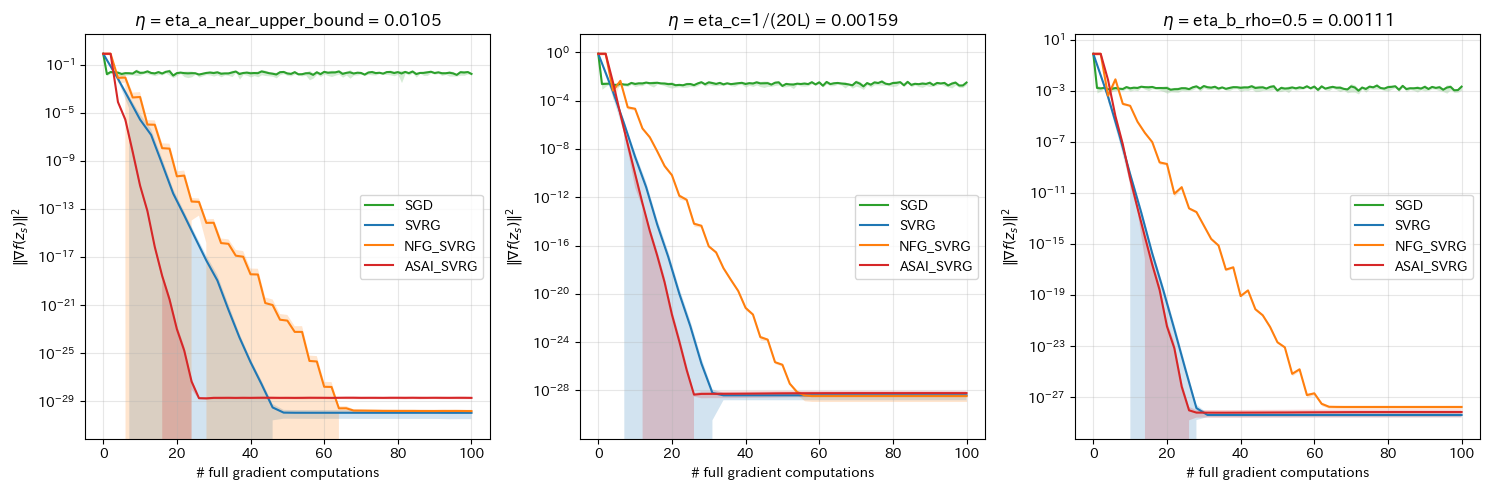

In [5]:
fig, axes = plt.subplots(1, len(HYPERPARAMS_LIST), figsize=(5 * len(HYPERPARAMS_LIST), 5))
axes = np.atleast_1d(axes)

for ax, hyperparams in zip(axes, HYPERPARAMS_LIST):
    plot_curves(ax, all_results, EXPERIMENT, hyperparams, METHODS, METHOD_COLORS,
                x_key="full_grad_computations", y_key="grad_norm_sq", x_limit=100)
    ax.set_xlabel("# full gradient computations")
    ax.set_ylabel(r"$\|\nabla f(z_s)\|^2$")
    ax.set_title(HYPERPARAMS_TO_LABEL[hyperparams])
    ax.legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / "grad_norm_sq_vs_full_grad_computations.png", dpi=150, bbox_inches="tight")
plt.show()

## 3つの横軸 × 3つの評価指標の比較

`.orders/order_020.md` の「共通の評価指標」に従い，横軸を勾配計算回数・エポック数・実行時間の
3通り，縦軸を目的関数の値・フル勾配のノルムの2乗・フル勾配の近似誤差の3通りとした比較を行う．
実行時間には，評価指標の算出のためだけに計算するフル勾配のコストは含まれていない．

/tmp/ipykernel_155033/1372621914.py:19: RuntimeWarning: Mean of empty slice
  return x_values.mean(axis=0), np.nanmean(y_values, axis=0), np.nanstd(y_values, axis=0)
/home/user/workspace/ASAI_SVRG_programs/.venv_pytorch/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


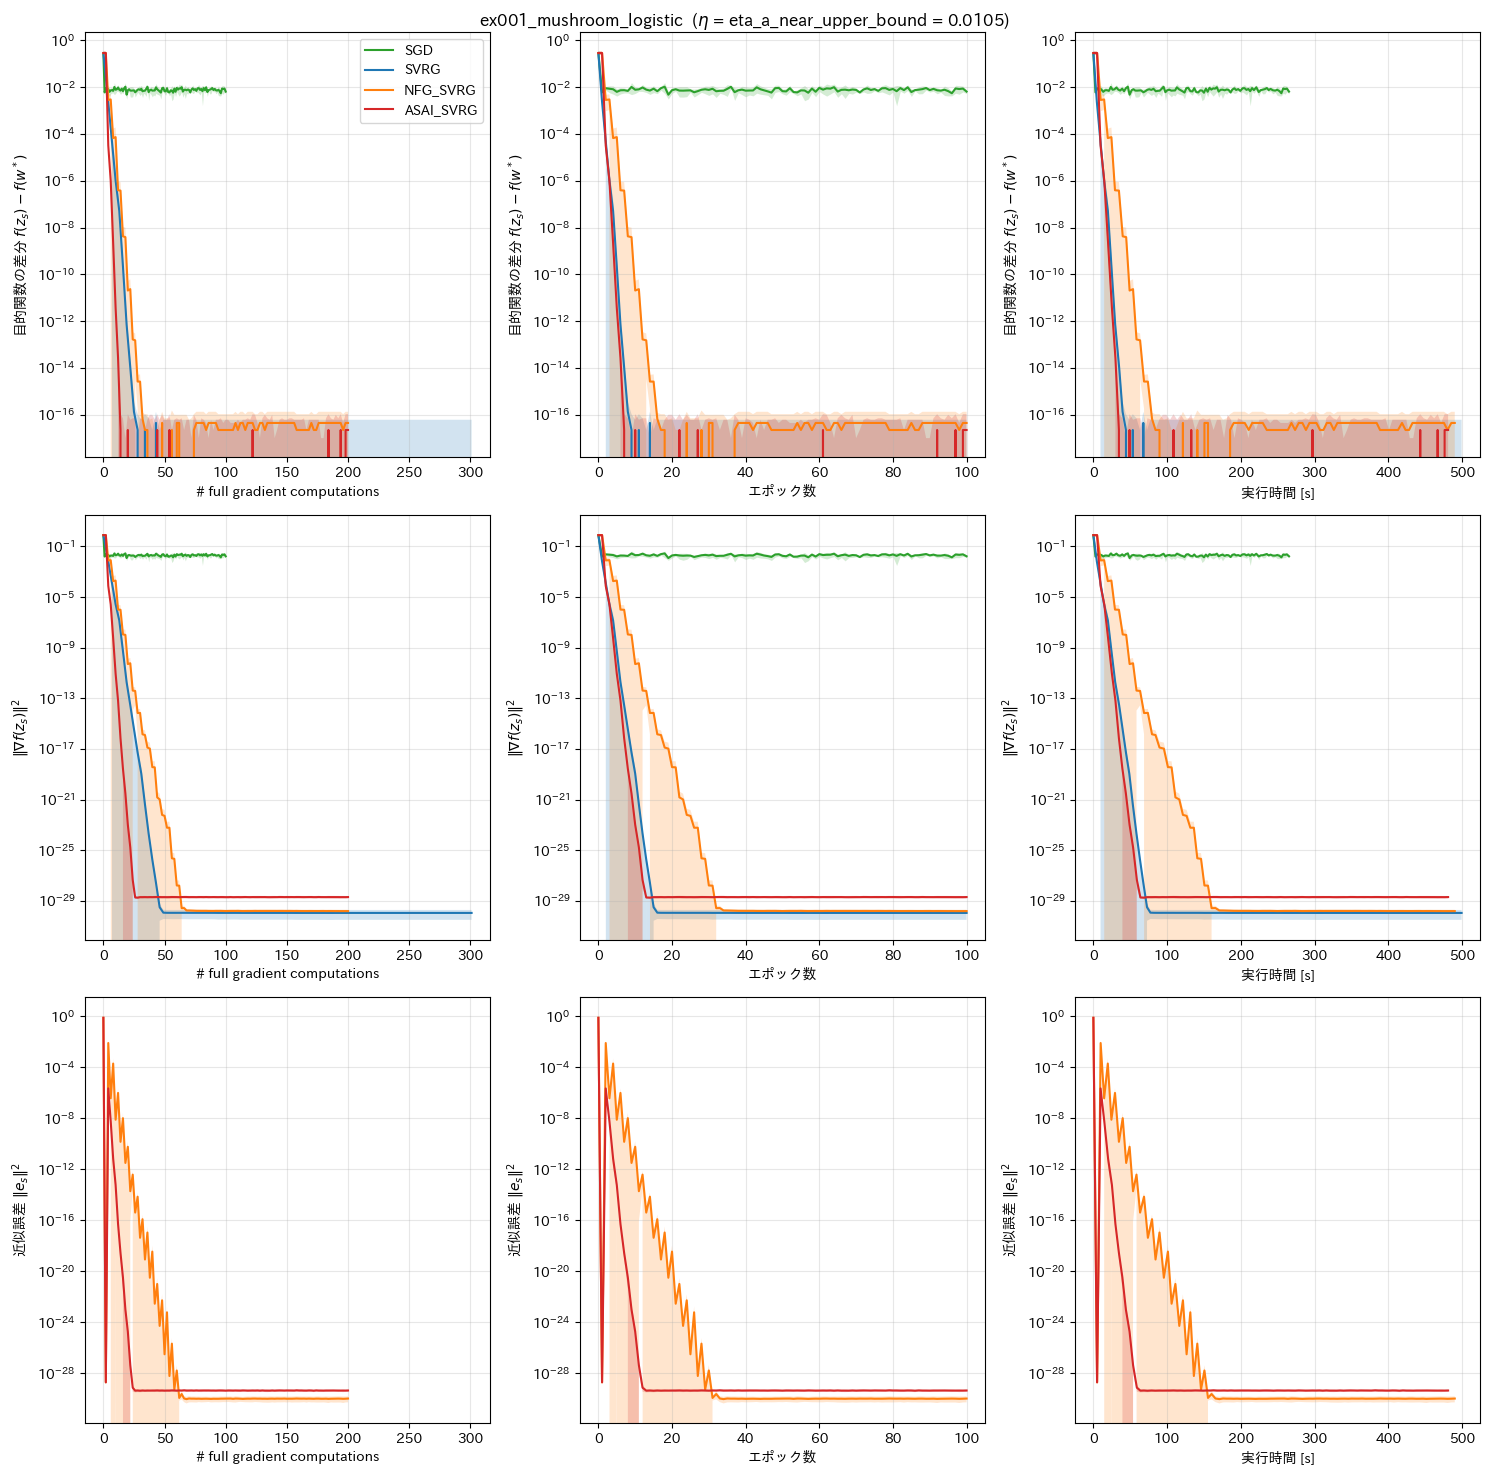

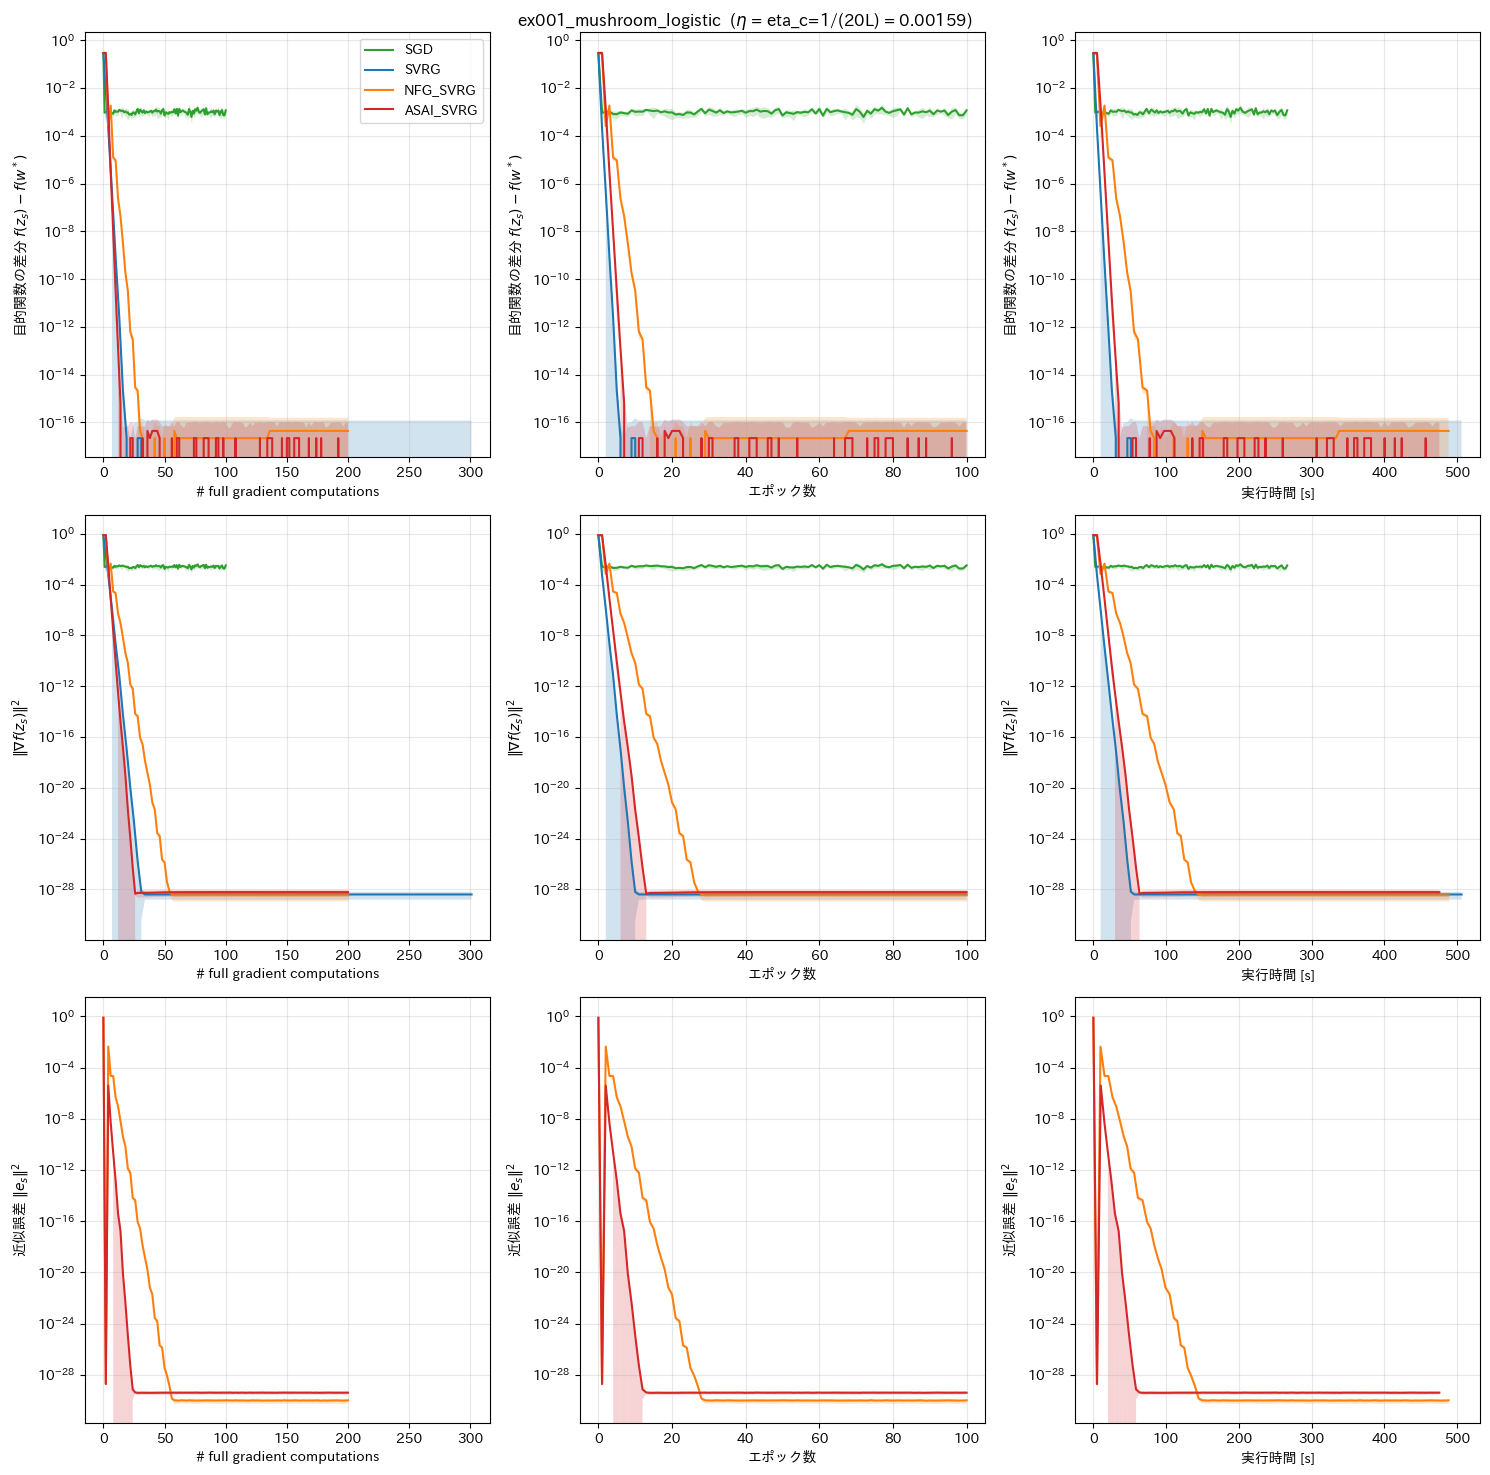

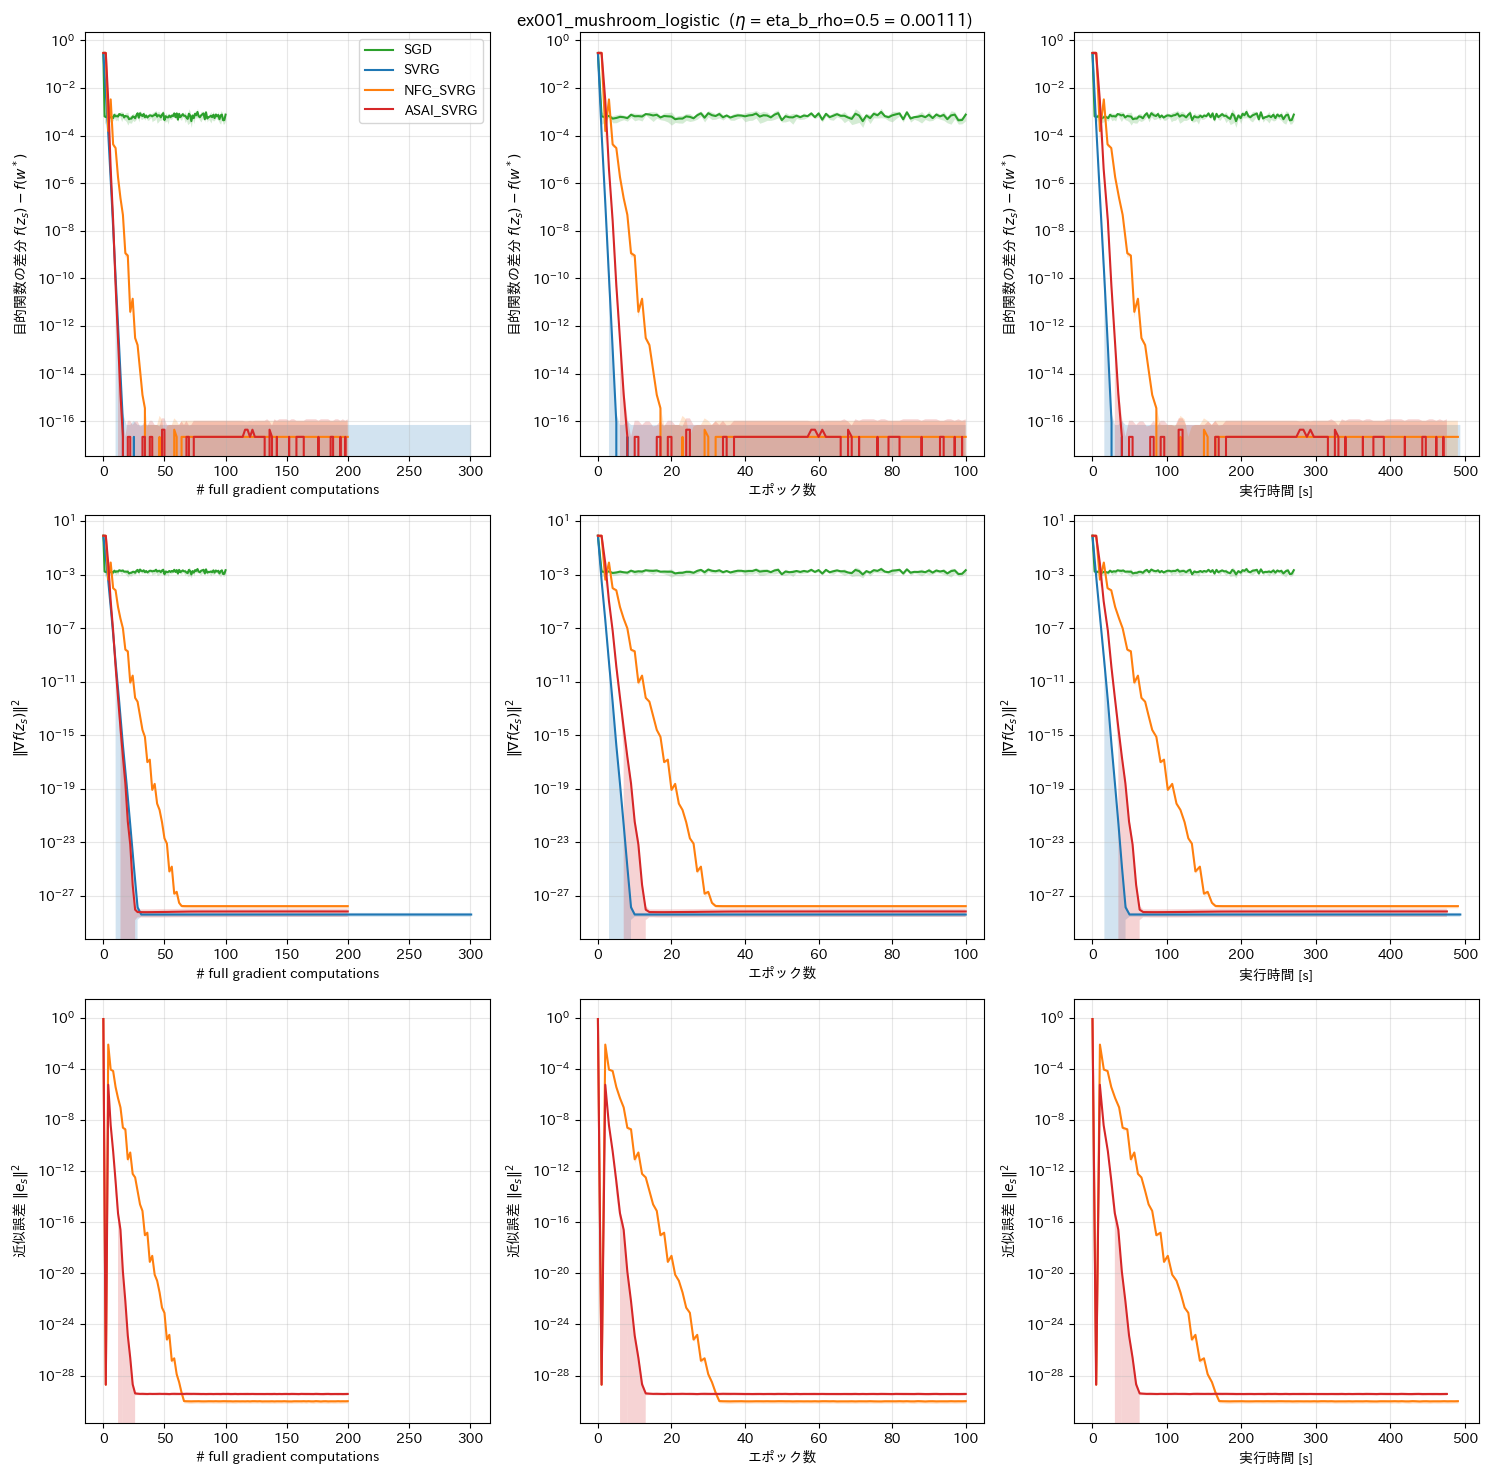

In [6]:
X_AXES = [
    ("full_grad_computations", "# full gradient computations"),
    ("epoch", "エポック数"),
    ("elapsed_time", "実行時間 [s]"),
]
Y_AXES = [
    (OBJECTIVE_KEY, OBJECTIVE_LABEL),
    ("grad_norm_sq", r"$\|\nabla f(z_s)\|^2$"),
    ("approx_error", r"近似誤差 $\|e_s\|^2$"),
]

for hyperparams in HYPERPARAMS_LIST:
    fig, axes = plt.subplots(len(Y_AXES), len(X_AXES), figsize=(15, 15))
    for row, (y_key, y_label) in enumerate(Y_AXES):
        for col, (x_key, x_label) in enumerate(X_AXES):
            ax = axes[row][col]
            plot_curves(ax, all_results, EXPERIMENT, hyperparams, METHODS, METHOD_COLORS,
                        x_key=x_key, y_key=y_key)
            ax.set_xlabel(x_label)
            ax.set_ylabel(y_label)
            if row == 0 and col == 0:
                ax.legend()

    fig.suptitle(f"{EXPERIMENT}  ({HYPERPARAMS_TO_LABEL[hyperparams]})")
    fig.tight_layout()
    eta_tag = hyperparams.split("_")[0]
    fig.savefig(FIGURE_DIR / f"comparison_all_axes_{eta_tag}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 分類精度の推移

原論文の式(8)は分類精度を評価指標としないが，`.orders/order_020.md` の共通の評価指標に従い，
検証用データに対する分類精度を補助指標として記録している．

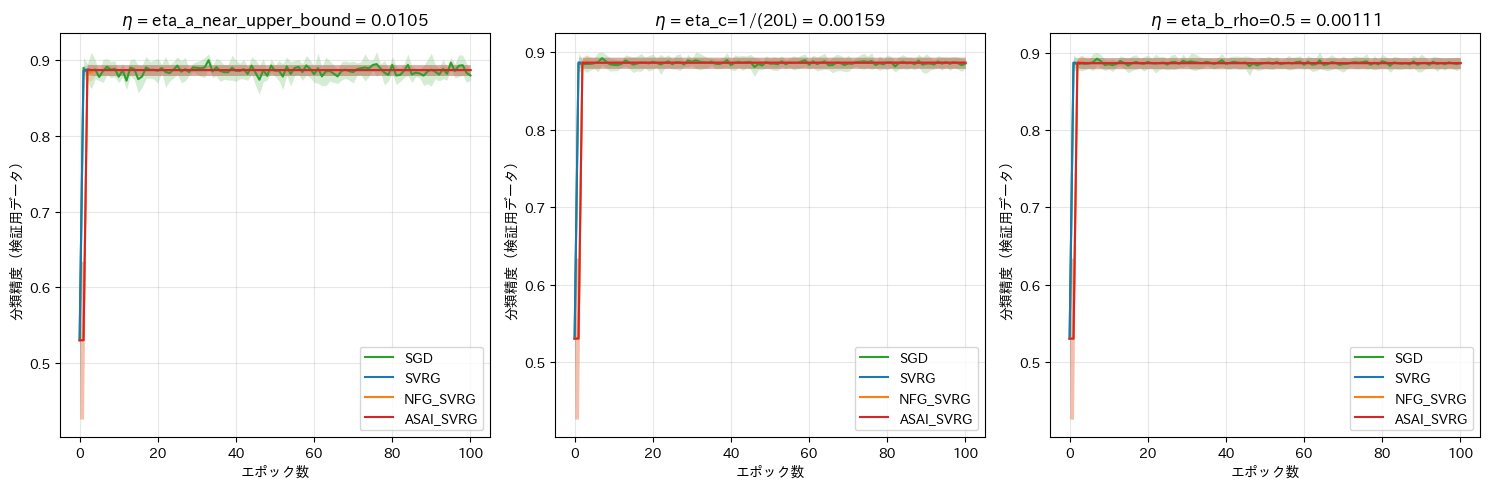

In [7]:
fig, axes = plt.subplots(1, len(HYPERPARAMS_LIST), figsize=(5 * len(HYPERPARAMS_LIST), 5))
axes = np.atleast_1d(axes)

for ax, hyperparams in zip(axes, HYPERPARAMS_LIST):
    plot_curves(ax, all_results, EXPERIMENT, hyperparams, METHODS, METHOD_COLORS,
                x_key="epoch", y_key="accuracy", log_y=False)
    ax.set_xlabel("エポック数")
    ax.set_ylabel("分類精度（検証用データ）")
    ax.set_title(HYPERPARAMS_TO_LABEL[hyperparams])
    ax.legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / "accuracy_vs_epoch.png", dpi=150, bbox_inches="tight")
plt.show()

## 最終エポックにおける評価指標の一覧

各条件の最終エポックにおける評価指標について，全Seedの平均と標準偏差を表形式で出力する．

In [8]:
def summarize_final_epoch(all_results, experiment, hyperparams_list, methods,
                          hyperparams_to_label, objective_key="objective_value") -> str:
    """
    概要: 各条件の最終エポックにおける評価指標（全Seedの平均 ± 標準偏差）をMarkdownの表として
        文字列にまとめる．
    引数:
        all_results (dict)．`load_all_results` の戻り値．
        experiment (str)．対象実験名．
        hyperparams_list (list of str)．対象とするハイパーパラメータ条件名のリスト．
        methods (list of str)．対象とする手法名のリスト．
        hyperparams_to_label (dict)．{ハイパーパラメータ条件名: ラベル文字列}．
        objective_key (str) = "objective_value"．目的関数を表す指標名．非凸実験では
            "objective_value"，強凸実験では差分 "objective_gap" を用いる．
    戻り値: table (str)．Markdown形式の表．
    """
    objective_header = "f(z_s)-f(w*)" if objective_key == "objective_gap" else "f(z_s)"
    lines = [
        f"| 学習率 | 手法 | {objective_header} | 精度 | ||\u2207f(z_s)||^2 | ||e_s||^2 | #grad/N | 実行時間[s] |",
        "| :--- | :--- | ---: | ---: | ---: | ---: | ---: | ---: |",
    ]
    for hyperparams in hyperparams_list:
        for method in methods:
            entry = all_results.get((experiment, method, hyperparams))
            if entry is None:
                continue
            cells = []
            for key in [objective_key, "accuracy", "grad_norm_sq", "approx_error",
                        "full_grad_computations", "elapsed_time"]:
                _, mean, std = aggregate_seeds(entry["seed_logs"], "epoch", key)
                if np.isnan(mean[-1]):
                    cells.append("なし")
                elif key == "accuracy":
                    cells.append(f"{mean[-1]:.4f} \u00b1 {std[-1]:.4f}")
                elif key in ("full_grad_computations", "elapsed_time"):
                    cells.append(f"{mean[-1]:.1f}")
                else:
                    cells.append(f"{mean[-1]:.4e} \u00b1 {std[-1]:.2e}")
            label = hyperparams_to_label[hyperparams]
            lines.append(f"| {label} | {method} | " + " | ".join(cells) + " |")
    return "\n".join(lines)


summary_table = summarize_final_epoch(
    all_results, EXPERIMENT, HYPERPARAMS_LIST, METHODS, HYPERPARAMS_TO_LABEL,
    objective_key=OBJECTIVE_KEY,
)
print(summary_table)
with open(FIGURE_DIR / "final_epoch_summary.md", "w") as f:
    f.write(summary_table + "\n")


| 学習率 | 手法 | f(z_s)-f(w*) | 精度 | ||∇f(z_s)||^2 | ||e_s||^2 | #grad/N | 実行時間[s] |
| :--- | :--- | ---: | ---: | ---: | ---: | ---: | ---: |
| $\eta$ = eta_a_near_upper_bound = 0.0105 | SGD | 6.5333e-03 ± 1.14e-03 | 0.8795 ± 0.0060 | 1.6562e-02 ± 2.89e-03 | なし | 100.0 | 265.4 |
| $\eta$ = eta_a_near_upper_bound = 0.0105 | SVRG | -2.2204e-17 ± 8.31e-17 | 0.8866 ± 0.0072 | 1.1241e-30 ± 8.05e-31 | 0.0000e+00 ± 0.00e+00 | 301.0 | 499.5 |
| $\eta$ = eta_a_near_upper_bound = 0.0105 | NFG_SVRG | 4.4409e-17 ± 8.88e-17 | 0.8866 ± 0.0072 | 1.5694e-30 ± 4.21e-31 | 1.0286e-30 ± 5.11e-31 | 200.0 | 490.2 |
| $\eta$ = eta_a_near_upper_bound = 0.0105 | ASAI_SVRG | 2.2204e-17 ± 8.31e-17 | 0.8866 ± 0.0072 | 2.0095e-29 ± 4.40e-30 | 4.3951e-30 ± 9.49e-31 | 200.0 | 481.2 |
| $\eta$ = eta_c=1/(20L) = 0.00159 | SGD | 1.1664e-03 ± 3.61e-04 | 0.8856 ± 0.0059 | 3.2330e-03 ± 1.04e-03 | なし | 100.0 | 266.5 |
| $\eta$ = eta_c=1/(20L) = 0.00159 | SVRG | 0.0000e+00 ± 1.22e-16 | 0.8866 ± 0.0072 | 3.9435e-29 ± 2.41e-29 |

/tmp/ipykernel_155033/1372621914.py:19: RuntimeWarning: Mean of empty slice
  return x_values.mean(axis=0), np.nanmean(y_values, axis=0), np.nanstd(y_values, axis=0)
